# Mode Sources, Pulsed Excitation, and S-Parameters in ExtrduedPolygon as a component in FDTDX

This notebook is a practical, hands-on tutorial on three closely related pieces of any
photonics FDTD workflow, using [FDTDX](https://github.com/ymahlau/fdtdx), the JAX-based FDTD
package developed

1. **`ModeSource`** – launching the fundamental waveguide mode into a structure, instead of
   a generic point/plane dipole.
2. **Pulsed source** – exciting the structure with a short broadband pulse instead of a
   continuous wave, so a *single* simulation yields a response over a whole wavelength range.
3. **`ModeDetector`** – decomposing the field at an output (and input) waveguide back into
   modal amplitudes, which is exactly what you need to measure transmission.

We then connect the modal amplitudes measured by the detectors to the **scattering
parameters (S-parameters)** that describe the device as a two-port network.

### The test device: an adiabatic taper built from `ExtrudedPolygon`

The device is a silicon strip waveguide that widens from 460 nm to 700 nm — but this time,
instead of an abrupt step made of two rectangular blocks, the transition is a smooth,
trapezoidal **taper**, built with the `ExtrudedPolygon` class: a 2D polygon (given as a
list of (x, y) vertices, centered at the origin) that gets extruded along one axis to a
fixed thickness. This is the natural way to represent any non-rectangular photonic
footprint in FDTDX — tapers, bends, rings, or shapes imported straight from a GDS layout.

A smooth taper should reflect much less light than an abrupt step of the same width
change, which gives us a nice, concrete way to see the S-parameters respond to a geometry
change.

> This notebook assumes `fdtdx` (and its plotting/optional video extras) are installed:
> `pip install fdtdx`.


In [19]:
import jax
import jax.numpy as jnp
import numpy as np
from matplotlib import pyplot as plt

import fdtdx

%matplotlib inline
jax.config.update("jax_platform_name", "cpu")  # remove/comment out if you have a GPU


## 1. Simulation config and materials

Like every FDTDX simulation, we start with a `SimulationConfig` (grid resolution, total
simulated time, numerical dtype, Courant factor) and a dictionary of `Material` objects
that will later be referenced by name from the geometry.

We'll simulate a silicon-on-insulator (SOI) strip waveguide: silicon core
(n ≈ 3.45), silica cladding/substrate (n ≈ 1.44), and air above.


In [22]:
resolution = 20e-9  # 20 nm Yee grid spacing

config = fdtdx.SimulationConfig(
    time=200e-15,          # 200 fs of simulated time
    grid=fdtdx.UniformGrid(spacing=resolution),
    backend="cpu",   # switch to "gpu" if you have CUDA/ROCM
    dtype=jnp.float32,
    courant_factor=0.99,
)

materials = {
    "silicon": fdtdx.Material(permittivity=3.45**2),
    "silica": fdtdx.Material(permittivity=1.44**2),
}


## 2. Geometry: input waveguide -> `ExtrudedPolygon` taper -> output waveguide

The simulation volume is 6 µm x 1.6 µm x 1.6 µm. A silica substrate sits at the bottom;
on top of it, three silicon pieces sit end-to-end along the propagation axis (x), each
220 nm tall:

* a straight **input waveguide**, 460 nm wide, 2 µm long — a plain rectangular block, so
  it's built with `UniformMaterialObject` like before,
* a **taper**, 2 µm long, widening from 460 nm to 700 nm — this is *not* a rectangle, so
  it's built as an `ExtrudedPolygon`,
* a straight **output waveguide**, 700 nm wide, 2 µm long — another `UniformMaterialObject`.

### Building the taper polygon

`ExtrudedPolygon` (reproduced below from the module you shared) takes:

* `axis` — the extrusion axis. We extrude along **z** (`axis=2`), i.e. the polygon lives in
  the x-y plane and gets a fixed thickness in z — exactly a lithographically patterned
  waveguide layer of constant etch depth.
* `vertices` — an `(N, 2)` array of (x, y) points **centered at the origin**, in meters.
* `material_name` / `materials` — which material (by name, from the same materials dict
  used everywhere else) fills the polygon.
* `partial_real_shape` — only the *extrusion axis* entry (z, the 220 nm thickness) needs
  to be given. As the docstring states, the in-plane size (x and y here) is inferred
  automatically from the vertex bounding box, and the class actively **raises an exception**
  if you try to specify `partial_real_shape`/`partial_grid_shape` for those axes yourself:

  ```python
  if real_shape[ax] is not None:
      raise Exception(
          f"ExtrudedPolygon {self.name}: partial_real_shape for axis {ax} is derived from the "
          f"vertex bounding box ({size:.3e} m). Do not specify it explicitly."
      )
  ```

So we only ever pass the vertices and the thickness — the footprint follows automatically.


In [25]:
wg_height = 220e-9
wg_in_width = 460e-9
wg_out_width = 700e-9

in_length = 2.0e-6
taper_length = 2.0e-6
out_length = 2.0e-6

# Trapezoid vertices, centered at the origin: narrow (wg_in_width) on the -x side,
# wide (wg_out_width) on the +x side. Wound counter-clockwise.
taper_vertices = np.array([
    [-taper_length / 2, -wg_in_width / 2],
    [taper_length / 2, -wg_out_width / 2],
    [taper_length / 2, wg_out_width / 2],
    [-taper_length / 2, wg_in_width / 2],
])

waveguide_in = fdtdx.UniformMaterialObject(
    name="waveguide_in",
    partial_real_shape=(in_length, wg_in_width, wg_height),
    material=materials["silicon"],
    color=fdtdx.colors.GREEN,
)

taper = fdtdx.ExtrudedPolygon(
    name="taper",
    axis=2,
    material_name="silicon",
    materials=materials,
    vertices=taper_vertices,
    partial_real_shape=(None, None, wg_height),
    color=fdtdx.colors.GREEN,
)

waveguide_out = fdtdx.UniformMaterialObject(
    name="waveguide_out",
    partial_real_shape=(out_length, wg_out_width, wg_height),
    material=materials["silicon"],
    color=fdtdx.colors.GREEN,
)


> **Note — building the same taper from a GDS file.** If you already have this shape laid
> out in a `.gds` file (e.g. exported from a mask-layout tool), the module you shared also
> provides `extruded_polygon_from_gds_path(gds_file, cell_name, layer, axis=2,
> material_name="silicon", materials=materials, ...)`, which reads the polygon straight off
> the given layer/datatype, centers its vertices automatically, and returns an
> `ExtrudedPolygon` ready to place — no need to type out vertices by hand. We use explicit
> vertices here purely so the notebook is self-contained.


In [28]:
volume = fdtdx.SimulationVolume(
    partial_real_shape=(6.0e-6, 1.6e-6, 1.6e-6),
)

bound_cfg = fdtdx.BoundaryConfig.from_uniform_bound(thickness=10, boundary_type="pml")
bound_dict, boundary_constraints = fdtdx.boundary_objects_from_config(bound_cfg, volume)

substrate = fdtdx.UniformMaterialObject(
    name="substrate",
    partial_real_shape=(None, None, 0.6e-6),
    material=materials["silica"],
    color=fdtdx.colors.BROWN,
)

constraints = [*boundary_constraints]
constraints.append(substrate.place_relative_to(volume, axes=2, own_positions=-1, other_positions=-1))

# input segment: flush with the left face of the volume, centered transversally, on the substrate
constraints.append(waveguide_in.place_relative_to(volume, axes=0, own_positions=-1, other_positions=-1))
constraints.append(waveguide_in.place_at_center(volume, axes=1))
constraints.append(waveguide_in.place_above(substrate))

# taper: touching the right face of the input waveguide
constraints.append(taper.face_to_face_positive_direction(waveguide_in, axes=0))
constraints.append(taper.place_at_center(volume, axes=1))
constraints.append(taper.place_above(substrate))

# output segment: touching the right face of the taper
constraints.append(waveguide_out.face_to_face_positive_direction(taper, axes=0))
constraints.append(waveguide_out.place_at_center(volume, axes=1))
constraints.append(waveguide_out.place_above(substrate))


## 3. `ModeSource`: launching a waveguide mode

A generic dipole or plane-wave source would excite every mode and radiation pattern the
structure supports, wasting most of its energy and making later analysis messy. A
**`ModePlaneSource`** instead:

1. runs a local mode solve on the cross-section it sits in (here, a `wave_character`
   picks the wavelength at which that mode solve happens),
2. injects *only* that transverse field pattern (the fundamental TE mode, `mode_index=0`),
   scaled by whatever time signal the source's `temporal_profile` specifies.

Note the separation of concerns: `wave_character` fixes the **spatial shape** of the
injected field (the mode profile, solved once), while `temporal_profile` fixes **how that
shape is scaled over time** — a pure sine wave, a pulse, or an arbitrary signal.

We first build the source with the default, continuous-wave `SingleFrequencyProfile`,
just to sanity-check the mode itself, before switching to a pulse in the next section.


In [31]:
carrier = fdtdx.WaveCharacter(wavelength=1.55e-6)

source = fdtdx.ModePlaneSource(
    name="source",
    partial_grid_shape=(1, None, None),
    wave_character=carrier,
    direction="+",
    mode_index=0,
    filter_pol="te",
    color=fdtdx.colors.GREEN,
)

constraints.append(
    source.place_relative_to(volume, axes=0, own_positions=-1, other_positions=-1, margins=1.0e-6)
)


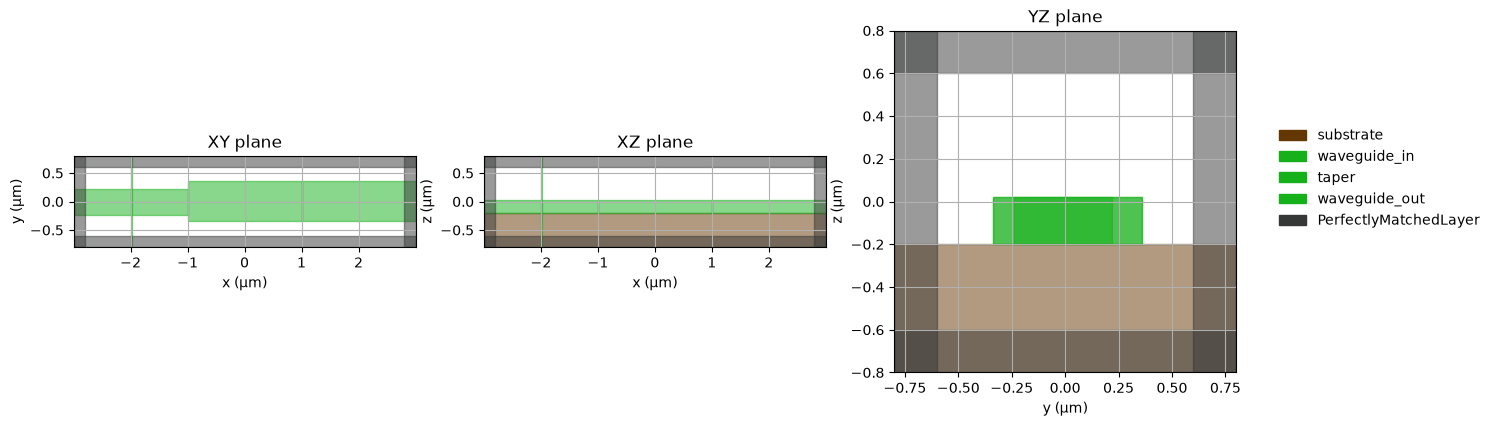

In [33]:
# Quick sanity check: solve the geometry and inspect the mode profile that will be launched
objects, arrays, params, config, _ = fdtdx.place_objects(
    object_list=[volume, substrate, waveguide_in, taper, waveguide_out, source, *bound_dict.values()],
    config=config,
    constraints=constraints,
    key=jax.random.PRNGKey(0),
)

fdtdx.plot_setup(config=config, objects=objects)


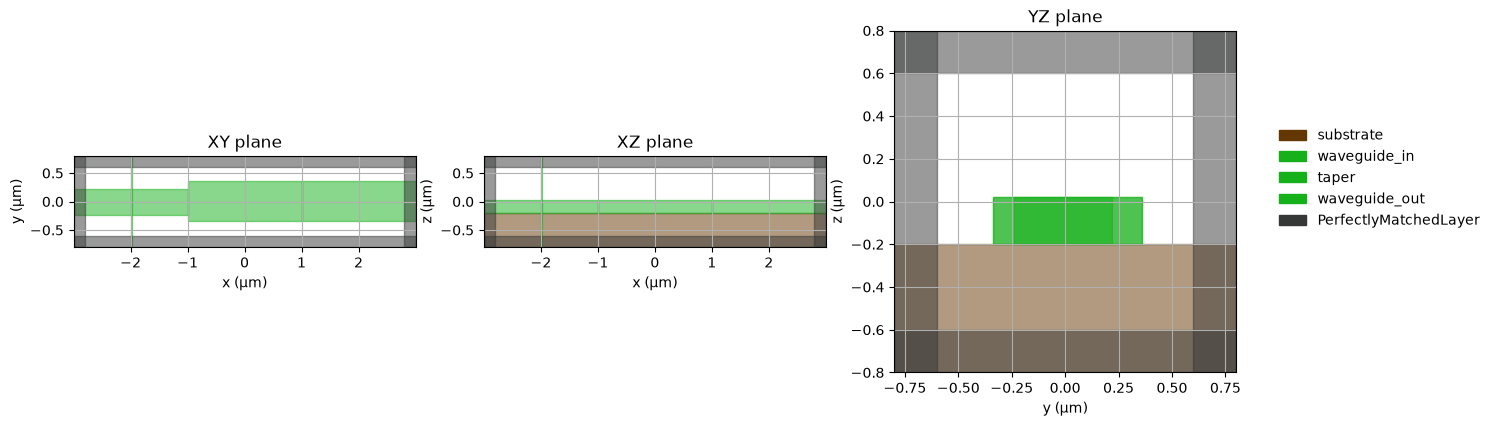

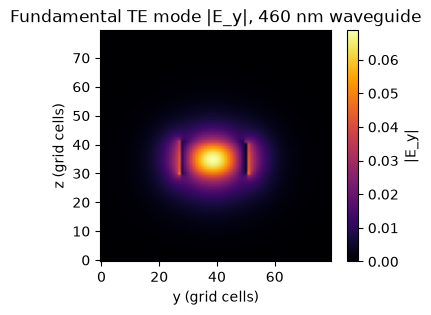

In [35]:
# The source object caches the solved mode fields once placed; inspect the dominant
# transverse E-field component of the fundamental TE mode it will inject.
src_obj = objects[source.name]
mode_field = np.abs(np.asarray(src_obj._E[1]))  # E_y component, squeezed 2D cross-section
plt.figure(figsize=(4, 3))
plt.imshow(mode_field.squeeze().T, origin="lower", cmap="inferno")
plt.title("Fundamental TE mode |E_y|, 460 nm waveguide")
plt.xlabel("y (grid cells)")
plt.ylabel("z (grid cells)")
plt.colorbar(label="|E_y|")
plt.show()


## 4. Pulsed source: getting a whole spectrum from one run

A continuous-wave `SingleFrequencyProfile` only tells you the steady-state response *at
one wavelength*. To characterize the taper over a band — say 1.50–1.60 µm — the standard
FDTD trick is to excite the structure with a short **broadband pulse** and record the
time-domain response; a single run then gives you the frequency response at as many
wavelengths as you like via on-the-fly discrete Fourier transforms.

FDTDX exposes this as a `GaussianPulseProfile`: a Gaussian-enveloped sinusoid, specified by
a center wavelength/frequency and a spectral width (again expressed as a `WaveCharacter`,
this time describing the width of the envelope in frequency/wavelength space rather than
an absolute value).

We rebuild the source with this pulsed profile. The `wave_character` used for the modal
solve stays fixed at the center wavelength — the mode shape barely changes over this
bandwidth for a well-guided mode, which is exactly the approximation that lets a single
mode source be used at all nearby wavelengths.


In [38]:
pulse_profile = fdtdx.GaussianPulseProfile(
    center_wave=fdtdx.WaveCharacter(wavelength=1.55e-6),
    spectral_width=fdtdx.WaveCharacter(wavelength=120e-9),
)

source = fdtdx.ModePlaneSource(
    name="source",
    partial_grid_shape=(1, None, None),
    wave_character=carrier,
    temporal_profile=pulse_profile,
    direction="+",
    mode_index=0,
    filter_pol="te",
    color=fdtdx.colors.GREEN,
)


## 5. `ModeOverlapDetector`: measuring transmission (and reflection)

A `ModeOverlapDetector` accumulates the time-domain field at a cross-section as a set of
running phasors (one per requested wavelength), then projects the accumulated field onto
the analytic mode profile via an overlap integral. That projected amplitude is the modal
coefficient of the field travelling in the detector's chosen `direction` — precisely a
scattering-parameter numerator or denominator.

We place two of them:

* **`reflection`**, inside the *input* waveguide, facing `"-"` (backward) — it will pick up
  light reflected by the taper, travelling back towards the source.
* **`transmission`**, inside the *output* waveguide, facing `"+"` (forward) — it picks up
  the light that made it through.

Both are evaluated at the same list of wavelengths, spanning the pulse bandwidth, so a
*single* pulsed run gives us a full transmission/reflection spectrum.


In [41]:
wavelengths = np.linspace(1.50e-6, 1.60e-6, 6)
wave_characters = [fdtdx.WaveCharacter(wavelength=float(w)) for w in wavelengths]

reflection_detector = fdtdx.ModeOverlapDetector(
    name="reflection",
    partial_grid_shape=(1, None, None),
    wave_characters=wave_characters,
    direction="-",
    mode_index=0,
    filter_pol="te",
    color=fdtdx.colors.PINK,
)
constraints.append(reflection_detector.place_at_center(waveguide_in, axes=0))

transmission_detector = fdtdx.ModeOverlapDetector(
    name="transmission",
    partial_grid_shape=(1, None, None),
    wave_characters=wave_characters,
    direction="+",
    mode_index=0,
    filter_pol="te",
    color=fdtdx.colors.PINK,
)
constraints.append(transmission_detector.place_at_center(waveguide_out, axes=0))

# Optional: an energy/field-intensity detector purely for visualization of the pulse
# passing through the taper (slower to run; comment out if you just want the S-parameters).
field_detector = fdtdx.EnergyDetector(
    name="fields",
    as_slices=True,
    switch=fdtdx.OnOffSwitch(interval=4),
)


## 6. Normalizing against a reference run

A modal overlap amplitude by itself is not yet an S-parameter: it is only meaningful
relative to how much light was actually launched into the mode in the first place. The
standard way to get that reference is a **normalization run**: simulate the *same* source
in a *bare* waveguide (no taper, no discontinuity at all) and record the modal amplitude
at the same reference plane where the device's input port will be. Since a straight,
lossless waveguide reflects nothing, this reference detector cleanly measures the incident
spectrum `a0(λ)`.

This mirrors exactly how S-parameter extraction works in tools like Lumerical, Tidy3D, or
Meep: one "through" reference simulation, then one simulation per device configuration,
with everything normalized against the reference.


In [44]:
key = jax.random.PRNGKey(42)
key, subkey = jax.random.split(key)

# --- Reference run: a single continuous waveguide at the INPUT width ---
ref_waveguide = fdtdx.UniformMaterialObject(
    name="waveguide_ref",
    partial_real_shape=(None, wg_in_width, wg_height),
    material=materials["silicon"],
    color=fdtdx.colors.GREEN,
)
ref_detector = fdtdx.ModeOverlapDetector(
    name="reference",
    partial_grid_shape=(1, None, None),
    wave_characters=wave_characters,
    direction="+",
    mode_index=0,
    filter_pol="te",
    color=fdtdx.colors.PINK,
)

ref_constraints = [
    *boundary_constraints,
    substrate.place_relative_to(volume, axes=2, own_positions=-1, other_positions=-1),
    ref_waveguide.place_above(substrate),
    ref_waveguide.place_at_center(volume, axes=1),
    source.place_relative_to(volume, axes=0, own_positions=-1, other_positions=-1, margins=1.0e-6),
    # same absolute reference plane as `reflection_detector` in the device run:
    # `in_length / 2` from the volume's left face, matching waveguide_in's center.
    ref_detector.place_relative_to(volume, axes=0, own_positions=-1, other_positions=-1, margins=in_length / 2),
]

ref_objects, ref_arrays, ref_params, config, _ = fdtdx.place_objects(
    object_list=[volume, substrate, source, ref_waveguide, ref_detector, *bound_dict.values()],
    config=config,
    constraints=ref_constraints,
    key=subkey,
)

key, subkey = jax.random.split(key)
ref_arrays, ref_objects, _ = fdtdx.apply_params(ref_arrays, ref_objects, ref_params, subkey)
key, subkey = jax.random.split(key)
_, ref_arrays = jax.jit(fdtdx.run_fdtd)(ref_arrays, ref_objects, config, subkey)

a0 = ref_objects[ref_detector.name].compute_overlap(ref_arrays.detector_states[ref_detector.name])
print("Incident modal amplitude a0(lambda):", a0)


FDTD (checkpointed):   0%|                           | 0/5245 [00:00<?, ?step/s]

Incident modal amplitude a0(lambda): [ 9.3914688e-20+6.7802127e-20j -1.7104162e-19+2.1015520e-19j
  5.9918043e-20+6.3611656e-20j  1.8353228e-19-2.0884691e-19j
 -7.1468754e-20-7.4951876e-20j  1.4954875e-19-2.2272277e-19j]


## 7. Main run: the taper device

Now the actual device simulation: input waveguide, the `ExtrudedPolygon` taper, output
waveguide, the pulsed mode source, and the reflection/transmission detectors.


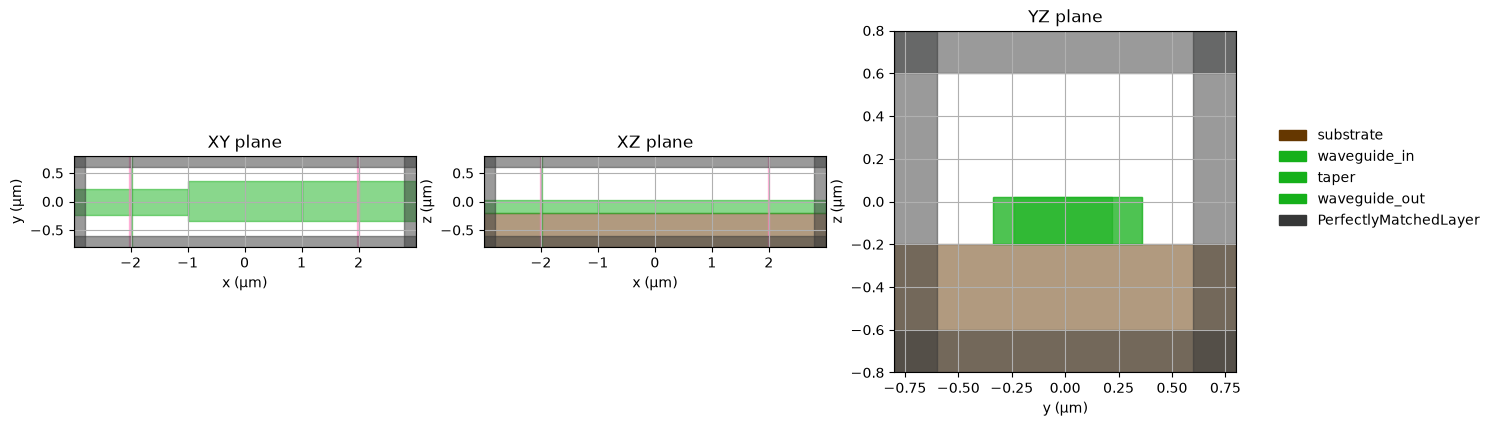

In [47]:
device_constraints = [
    *boundary_constraints,
    substrate.place_relative_to(volume, axes=2, own_positions=-1, other_positions=-1),
    waveguide_in.place_relative_to(volume, axes=0, own_positions=-1, other_positions=-1),
    waveguide_in.place_at_center(volume, axes=1),
    waveguide_in.place_above(substrate),
    taper.face_to_face_positive_direction(waveguide_in, axes=0),
    taper.place_at_center(volume, axes=1),
    taper.place_above(substrate),
    waveguide_out.face_to_face_positive_direction(taper, axes=0),
    waveguide_out.place_at_center(volume, axes=1),
    waveguide_out.place_above(substrate),
    source.place_relative_to(volume, axes=0, own_positions=-1, other_positions=-1, margins=1.0e-6),
    reflection_detector.place_at_center(waveguide_in, axes=0),
    transmission_detector.place_at_center(waveguide_out, axes=0),
]

device_object_list = [
    volume, substrate, source, waveguide_in, taper, waveguide_out,
    reflection_detector, transmission_detector, field_detector,
    *bound_dict.values(),
]

key, subkey = jax.random.split(key)
objects, arrays, params, config, _ = fdtdx.place_objects(
    object_list=device_object_list,
    config=config,
    constraints=device_constraints,
    key=subkey,
)

fdtdx.plot_setup(config=config, objects=objects)


In [49]:
key, subkey = jax.random.split(key)
arrays, objects, info = fdtdx.apply_params(arrays, objects, params, subkey)

key, subkey = jax.random.split(key)
_, arrays = jax.jit(fdtdx.run_fdtd)(arrays, objects, config, subkey)


FDTD (checkpointed):   0%|                           | 0/5245 [00:00<?, ?step/s]

In [51]:
b1 = objects[reflection_detector.name].compute_overlap(arrays.detector_states[reflection_detector.name])
b2 = objects[transmission_detector.name].compute_overlap(arrays.detector_states[transmission_detector.name])

print("Reflected modal amplitude b1(lambda):  ", b1)
print("Transmitted modal amplitude b2(lambda):", b2)


Reflected modal amplitude b1(lambda):   [-4.6888794e-20-3.8533417e-21j -3.5959984e-20-2.3520806e-20j
 -5.6373658e-20-2.6182921e-20j  3.5963790e-20+5.0502135e-21j
  4.0187077e-20+4.2404988e-20j  7.4326391e-20-3.9639242e-21j]
Transmitted modal amplitude b2(lambda): [-1.4713527e-19+5.4308279e-19j -5.1476866e-19+2.2438561e-19j
 -5.0332658e-19-2.5518773e-19j -1.3362780e-19-5.4591883e-19j
  3.1523530e-19-4.6562483e-19j  5.5757670e-19-8.4932540e-20j]


## 8. From modal amplitudes to S-parameters

With the incident amplitude `a0` from the reference run, and the reflected/transmitted
amplitudes `b1`, `b2` from the device run, the scattering parameters of this two-port
device are just:

$$ S_{11}(\lambda) = \frac{b_1(\lambda)}{a_0(\lambda)}, \qquad
   S_{21}(\lambda) = \frac{b_2(\lambda)}{a_0(\lambda)} $$

exactly the same definition used for a two-port RF/microwave network: `S11` is "how much
of what you sent in port 1 comes back out of port 1" (reflection), and `S21` is "how much
of what you sent in port 1 comes out of port 2" (transmission).

A couple of things worth noting:

* `|S21|²` is the fraction of *power* transmitted, and `|S11|²` the fraction reflected.
  `1 - |S11|² - |S21|²` is the power scattered elsewhere — into higher-order or radiation
  modes along the taper, which our two single-mode detectors don't capture.
* The absolute *phase* of S21 depends on where exactly you place the input/output
  reference planes (it includes the propagation phase between them), same as with any
  network-parameter measurement; only relative phases between multiple ports are
  meaningful without extra bookkeeping. For a transmission spectrum, the magnitude is
  usually what you care about.
* This two-run pattern (one reference/normalization run, one device run) is exactly how
  S-parameter extraction works in commercial FDTD tools too. For larger circuits with many
  ports, FDTDX also provides higher-level helpers, `fdtdx.setup_sparams_simulation` and
  `fdtdx.calculate_sparams`, that automate this per-port bookkeeping for GDS-defined
  multi-port devices — a natural next step once your device geometry comes from
  `extruded_polygon_from_gds_path` rather than hand-written vertices.


In [54]:
S11 = b1 / a0
S21 = b2 / a0

power_reflected = jnp.abs(S11) ** 2
power_transmitted = jnp.abs(S21) ** 2

for i, wl in enumerate(wavelengths):
    print(
        f"lambda = {wl*1e9:6.1f} nm   "
        f"|S11| = {float(power_reflected[i])**0.5:.3f} ({10*np.log10(float(power_reflected[i])+1e-12):6.1f} dB)   "
        f"|S21| = {float(power_transmitted[i])**0.5:.3f} ({10*np.log10(float(power_transmitted[i])+1e-12):6.1f} dB)   "
        f"sum = {float(power_reflected[i] + power_transmitted[i]):.3f}"
    )


lambda = 1500.0 nm   |S11| = 0.406 (  -7.8 dB)   |S21| = 4.858 (  13.7 dB)   sum = 23.761
lambda = 1520.0 nm   |S11| = 0.159 ( -16.0 dB)   |S21| = 2.072 (   6.3 dB)   sum = 4.320
lambda = 1540.0 nm   |S11| = 0.711 (  -3.0 dB)   |S21| = 6.458 (  16.2 dB)   sum = 42.207
lambda = 1560.0 nm   |S11| = 0.131 ( -17.7 dB)   |S21| = 2.021 (   6.1 dB)   sum = 4.103
lambda = 1580.0 nm   |S11| = 0.564 (  -5.0 dB)   |S21| = 5.429 (  14.7 dB)   sum = 29.797
lambda = 1600.0 nm   |S11| = 0.277 ( -11.1 dB)   |S21| = 2.102 (   6.5 dB)   sum = 4.497


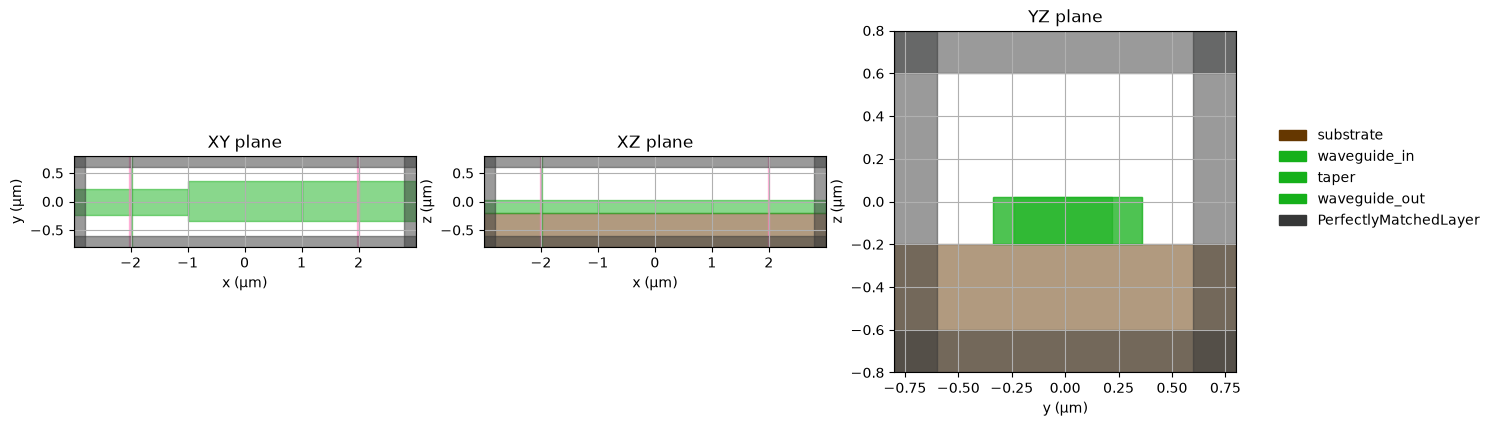

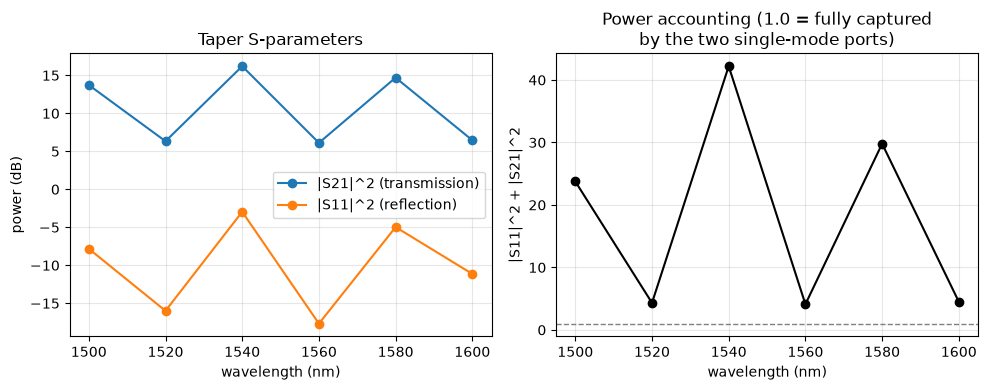

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(wavelengths * 1e9, 10 * np.log10(np.asarray(power_transmitted) + 1e-12), "o-", label="|S21|^2 (transmission)")
axes[0].plot(wavelengths * 1e9, 10 * np.log10(np.asarray(power_reflected) + 1e-12), "o-", label="|S11|^2 (reflection)")
axes[0].set_xlabel("wavelength (nm)")
axes[0].set_ylabel("power (dB)")
axes[0].set_title("Taper S-parameters")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(wavelengths * 1e9, np.asarray(power_transmitted) + np.asarray(power_reflected), "o-", color="k")
axes[1].axhline(1.0, color="gray", linestyle="--", linewidth=1)
axes[1].set_xlabel("wavelength (nm)")
axes[1].set_ylabel("|S11|^2 + |S21|^2")
axes[1].set_title("Power accounting (1.0 = fully captured\nby the two single-mode ports)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 9. (Optional) watching the pulse move through the taper

If you kept the `EnergyDetector` from section 5 in the device run, you can render the
recorded field slices into a short video to see the pulse widen smoothly as it crosses the
taper, with only a small reflected tail heading back towards the source.


In [61]:
video_info = objects[field_detector.name].draw_plot(
    state=arrays.detector_states[field_detector.name]
)
video_info  # inspect the returned path / figure, depending on the installed FDTDX version


{'sliced_video': '/var/folders/9c/sf1_5nb17v51rk1l8xcxshdc0000gn/T/tmpnmesd63f.mp4'}

## Summary

* **`ModePlaneSource`** launches a single, well-defined waveguide mode instead of a messy
  multi-mode excitation — `wave_character` sets *which spatial mode shape* is solved for,
  `temporal_profile` sets *how it's driven in time*.
* Swapping `SingleFrequencyProfile` for **`GaussianPulseProfile`** turns a single-wavelength
  CW simulation into a broadband run: one FDTD simulation, one Fourier transform per
  detector, a whole spectrum.
* **`ModeOverlapDetector`** decomposes the field back into modal amplitudes for a chosen
  propagation direction — put one facing backward at the input for reflection, one facing
  forward at the output for transmission.
* Normalizing device-run amplitudes by a **reference/through run**'s incident amplitude
  turns those modal amplitudes into proper **S-parameters**, `S11` and `S21`, with the same
  meaning (and the same power-conservation check, `|S11|² + |S21|² ≤ 1`) as in any
  microwave or photonic network analysis.
* **`ExtrudedPolygon`** is what let us describe the non-rectangular taper footprint at all:
  a set of (x, y) vertices centered at the origin, extruded to a fixed thickness along one
  axis, with the in-plane bounding box inferred automatically. The same class (via
  `extruded_polygon_from_gds_path`) is how you'd pull an arbitrarily complex shape straight
  out of a real mask layout instead of typing vertices by hand.

Natural next steps: compare this taper's S-parameters directly against the abrupt-step
version to quantify how much the smooth transition helps; sweep the taper length to find
the shortest adiabatic design that still keeps reflection below some target; or add more
ports (e.g. a splitter with two outputs) and feed the resulting S-parameters into a
circuit-level solver to model a larger photonic circuit built from many such FDTD-
characterized elements.
